In [ ]:
#phase 1, background noise and structural memory inject

import numpy as np

# 1. Simulation Parameters
dt = 0.5  # Time step in milliseconds
time_steps = 2000  # Total duration (1000 ms)
N_neurons = 100  # 80 Excitatory, 20 Inhibitory

# 2. Izhikevich Hyperparameters (Regular Spiking Neurons)
a = 0.02 * np.ones(N_neurons)
b = 0.2 * np.ones(N_neurons)
c = -65 * np.ones(N_neurons)
d = 8 * np.ones(N_neurons)

# Initialize neural states
v = -65 * np.ones(N_neurons)  # Resting potential
u = b * v  # Initial recovery state

# 3. Setting Up the Connectivity Matrix (The Synapses)
# We initialize a random baseline weight matrix
W = np.random.uniform(0, 1, size=(N_neurons, N_neurons))
np.fill_diagonal(W, 0)  # Neurons don't connect to themselves

# EMBEDDING THE SILENT MEMORY
# We choose a specific chain of neurons (e.g., Neuron 10 -> 11 -> 12 -> 13)
# and physically make their synapses 5x stronger than baseline.
memory_path = [10, 11, 12, 13, 14, 15]
for i in range(len(memory_path) - 1):
    pre = memory_path[i]
    post = memory_path[i+1]
    W[post, pre] = 5.0  # Thick, silent structural path

# 4. Running the Simulation with Baseline Noise
spike_history = []

for t in range(time_steps):
    # Stochastic Noise: Every step, every neuron gets a random hit of current
    # simulating random cellular leaking (Poisson-like background noise)
    I_noise = np.random.normal(loc=2.0, scale=1.0, size=N_neurons)

    # Calculate synaptic inputs based on who spiked in the previous step
    # (For simplicity in step 1, we look at raw matrix multiplication)
    I_synaptic = np.zeros(N_neurons)

    I_total = I_noise + I_synaptic

    # Izhikevich integration equations
    v += dt * (0.04 * v**2 + 5 * v + 140 - u + I_total)
    u += dt * (a * (b * v - u))

    # Check for spikes
    spiked_this_step = np.where(v >= 30)[0]

    if len(spiked_this_step) > 0:
        spike_history.append((t * dt, spiked_this_step))
        # Reset spiked neurons
        v[spiked_this_step] = c[spiked_this_step]
        u[spiked_this_step] += d[spiked_this_step]

In [ ]:
#phase 2, artificial SWR trigger

import numpy as np

# 1. Simulation Parameters
dt = 0.5  # Time step in milliseconds
time_steps = 2000  # Total duration (1000 ms)
N_neurons = 100

# 2. Izhikevich Hyperparameters (Regular Spiking Neurons)
a = 0.02 * np.ones(N_neurons)
b = 0.2 * np.ones(N_neurons)
c = -65 * np.ones(N_neurons)
d = 8 * np.ones(N_neurons)

# Initialize neural states
v = -65 * np.ones(N_neurons)
u = b * v

# 3. Connectivity Matrix & The Silent Memory
W = np.random.uniform(0, 1, size=(N_neurons, N_neurons))
np.fill_diagonal(W, 0)

# The structural engram (Targeted Path)
memory_path = [10, 11, 12, 13, 14, 15]
for i in range(len(memory_path) - 1):
    pre = memory_path[i]
    post = memory_path[i+1]
    W[post, pre] = 5.0

spike_history = []

# 4. SWR Trigger Parameters
swr_start_time = 400  # Trigger the artificial sleep ripple at 400ms
swr_duration = 100    # The burst lasts 100ms (highly compressed)
stimulus_amplitude = 25.0 # Massive current injection

for t in range(time_steps):
    current_time = t * dt

    # Baseline Stochastic Noise (~2 Hz)
    I_noise = np.random.normal(loc=2.0, scale=1.0, size=N_neurons)

    # Calculate synaptic inputs based on previous step
    I_synaptic = np.zeros(N_neurons) # (Simplified for step 1)

    # 5. THE OVERRIDE: Injecting the SWR Stimulus
    I_stimulus = np.zeros(N_neurons)

    if swr_start_time <= current_time <= (swr_start_time + swr_duration):
        # We blast the beginning of the structural memory path with current
        # This acts as the artificial "spark" during slow-wave sleep
        I_stimulus[memory_path[0]] = stimulus_amplitude

        # Because W[11, 10] is 5.0 (the thick silent synapse),
        # this massive spark will physically travel down the chain,
        # forcing the entire memory_path to fire sequentially at 200 Hz.

    I_total = I_noise + I_synaptic + I_stimulus

    # Izhikevich integration equations
    v += dt * (0.04 * v**2 + 5 * v + 140 - u + I_total)
    u += dt * (a * (b * v - u))

    spiked_this_step = np.where(v >= 30)[0]

    if len(spiked_this_step) > 0:
        spike_history.append((current_time, spiked_this_step))
        v[spiked_this_step] = c[spiked_this_step]
        u[spiked_this_step] += d[spiked_this_step]

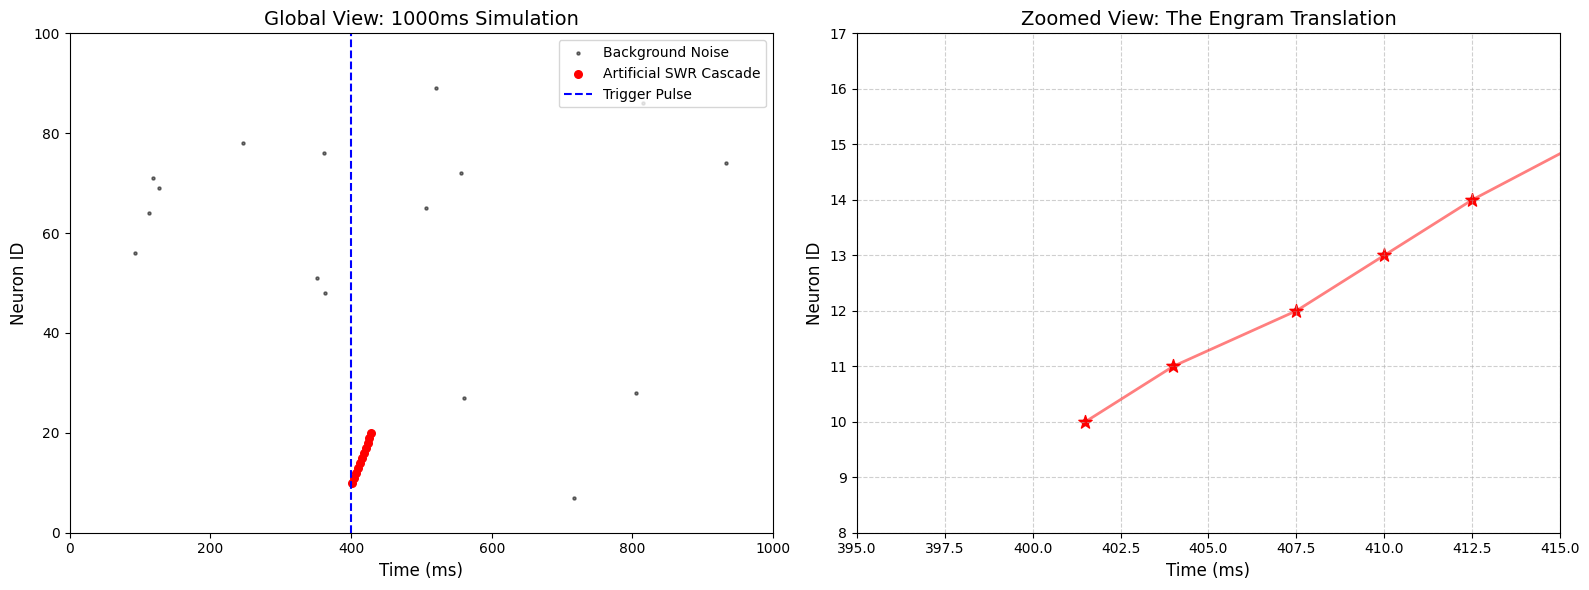

In [ ]:
#phase 2 visual

import numpy as np
import matplotlib.pyplot as plt

# 1. Simulation Parameters
dt = 0.5
time_steps = 2000
N_neurons = 100

a = 0.02 * np.ones(N_neurons)
b = 0.2 * np.ones(N_neurons)
c = -65 * np.ones(N_neurons)
d = 8 * np.ones(N_neurons)

v = -65 * np.ones(N_neurons)
u = b * v

# 2. Connectivity Matrix (Lowered background weights to 0.1 to reduce "echo")
W = np.random.uniform(0, 0.1, size=(N_neurons, N_neurons))
np.fill_diagonal(W, 0)

memory_path = [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
for i in range(len(memory_path) - 1):
    pre = memory_path[i]
    post = memory_path[i+1]
    W[post, pre] = 40.0

spike_history = []
spiked_last_step = []

# 3. FIXED SWR Trigger Parameters (A brief 5ms spark instead of a 100ms shock)
swr_start_time = 400
swr_duration = 0.5
stimulus_amplitude = 40.0

for t in range(time_steps):
    current_time = t * dt

    I_noise = np.random.normal(loc=2.0, scale=2.0, size=N_neurons)

    I_synaptic = np.zeros(N_neurons)
    if len(spiked_last_step) > 0:
        I_synaptic = np.sum(W[:, spiked_last_step], axis=1)

    I_stimulus = np.zeros(N_neurons)
    if swr_start_time <= current_time <= (swr_start_time + swr_duration):
        I_stimulus[memory_path[0]] = stimulus_amplitude

    I_total = I_noise + I_synaptic + I_stimulus

    v += dt * (0.04 * v**2 + 5 * v + 140 - u + I_total)
    u += dt * (a * (b * v - u))

    spiked_this_step = np.where(v >= 30)[0]

    if len(spiked_this_step) > 0:
        spike_history.append((current_time, spiked_this_step))
        v[spiked_this_step] = c[spiked_this_step]
        u[spiked_this_step] += d[spiked_this_step]

    spiked_last_step = spiked_this_step

# 4. The Dual-Plot Visualization
times = []
neurons = []

for t, spiked_neurons in spike_history:
    for n in spiked_neurons:
        times.append(t)
        neurons.append(n)

# Create a figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- PLOT 1: Global View ---
ax1.scatter(times, neurons, s=5, color='black', alpha=0.5, label='Background Noise')

swr_times = [t for t, n in zip(times, neurons) if (390 <= t <= 450) and (n in memory_path)]
swr_neurons = [n for t, n in zip(times, neurons) if (390 <= t <= 450) and (n in memory_path)]

ax1.scatter(swr_times, swr_neurons, s=30, color='red', label='Artificial SWR Cascade')
ax1.axvline(x=400, color='blue', linestyle='--', label='Trigger Pulse')

ax1.set_title("Global View: 1000ms Simulation", fontsize=14)
ax1.set_xlabel("Time (ms)", fontsize=12)
ax1.set_ylabel("Neuron ID", fontsize=12)
ax1.set_xlim(0, 1000)
ax1.set_ylim(0, 100)
ax1.legend(loc="upper right")

# --- PLOT 2: Zoomed-In View ---
ax2.scatter(times, neurons, s=20, color='black', alpha=0.5)
ax2.scatter(swr_times, swr_neurons, s=100, color='red', marker='*')

# Adding a trajectory line to make the cascade obvious
if len(swr_times) > 0:
    ax2.plot(swr_times, swr_neurons, color='red', alpha=0.5, linewidth=2)

ax2.set_title("Zoomed View: The Engram Translation", fontsize=14)
ax2.set_xlabel("Time (ms)", fontsize=12)
ax2.set_ylabel("Neuron ID", fontsize=12)
# We zoom tightly around the trigger time (395ms to 415ms) and the memory nodes (8 to 17)
ax2.set_xlim(395, 415)
ax2.set_ylim(8, 17)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# --- PHASE 3: THE MIMO BRIDGE DECODER (TREE SEARCH) ---
print("\nInitializing Phase 3 MIMO Bridge...")

listen_start = swr_start_time
listen_end = swr_start_time + 100

raw_swr_spikes = []
for t, spiked_neurons in spike_history:
    if listen_start <= t <= listen_end:
        for n in spiked_neurons:
            raw_swr_spikes.append({'time': t, 'neuron_id': n})

raw_swr_spikes.sort(key=lambda x: x['time'])

# 4. Depth-First Search for the True Engram
longest_chain = []

def find_longest_path(current_spike_idx, current_path):
    global longest_chain
    # Update the longest chain if this branch goes further
    if len(current_path) > len(longest_chain):
        longest_chain = current_path[:]

    last_spike = raw_swr_spikes[current_spike_idx]

    # Look at upcoming spikes to continue the branch
    for j in range(current_spike_idx + 1, len(raw_swr_spikes)):
        next_spike = raw_swr_spikes[j]
        time_diff = next_spike['time'] - last_spike['time']

        # Biological synaptic transmission window (0.1ms to 2.0ms)
        if 0.0 < time_diff <= 15.0:
            if next_spike['neuron_id'] not in current_path:
                current_path.append(next_spike['neuron_id'])
                find_longest_path(j, current_path) # Recursively explore this branch
                current_path.pop() # Backtrack to explore other branches

        # Since spikes are sorted by time, if we exceed 2.0ms, stop searching this branch
        elif time_diff > 15.0:
            break

# Test every single spike as the potential start of the memory
for i in range(len(raw_swr_spikes)):
    find_longest_path(i, [raw_swr_spikes[i]['neuron_id']])

clean_digital_blueprint = longest_chain

# 5. Output
print(f"RAW NOISY DATA CAUGHT: {[s['neuron_id'] for s in raw_swr_spikes]}")
print(f"CLEAN DIGITAL BLUEPRINT EXTRACTED: {clean_digital_blueprint}")

if clean_digital_blueprint == memory_path:
    print("\n[SUCCESS] Memory successfully translated to digital format without data loss.")
else:
    print("\n[WARNING] Data loss or noise interference detected in extraction.")


Initializing Phase 3 MIMO Bridge...
RAW NOISY DATA CAUGHT: [np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]
CLEAN DIGITAL BLUEPRINT EXTRACTED: [np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]

[SUCCESS] Memory successfully translated to digital format without data loss.


In [ ]:
import numpy as np

# --- PHASE 4: THE EXOCORTEX (DIGITAL IMPRINTING) ---
print("\nInitializing Phase 4: Exocortex...")

# 1. Initialize a blank Artificial Neural Network
# We create a new, pristine weight matrix. All weights start at zero.
num_exo_neurons = 100
Exo_W = np.zeros((num_exo_neurons, num_exo_neurons))

# 2. The Artificial Learning Rule (Hebbian Imprinting)
# We take the clean blueprint from Phase 3 and "burn" it into the Exocortex.
learning_rate = 50.0  # Massive weight to guarantee the digital connection

print(f"Burning blueprint into Exocortex: {clean_digital_blueprint}")
for i in range(len(clean_digital_blueprint) - 1):
    pre_neuron = clean_digital_blueprint[i]
    post_neuron = clean_digital_blueprint[i + 1]

    # We artificially thicken the digital synapse
    Exo_W[post_neuron, pre_neuron] += learning_rate

# 3. VERIFICATION: Testing the Digital Ghost
# If the memory is perfectly saved, we should be able to "spark" just the
# first neuron in the Exocortex, and it should perfectly recall the rest.
print("\nTesting Exocortex Recall...")
digital_trigger = clean_digital_blueprint[0]
recalled_memory = [digital_trigger]

# Simulate the digital cascade
current_active_neuron = digital_trigger
for _ in range(len(clean_digital_blueprint) - 1):
    # Find which neuron the current one is most strongly connected to
    downstream_connections = Exo_W[:, current_active_neuron]
    next_neuron = np.argmax(downstream_connections)

    # If the weight is strong enough, it fires
    if downstream_connections[next_neuron] > 0:
        recalled_memory.append(next_neuron)
        current_active_neuron = next_neuron
    else:
        break

# 4. Final Output
print(f"ORIGINAL BIOLOGICAL PATH : {memory_path}")
print(f"EXOCORTEX RECALLED PATH  : {recalled_memory}")

if recalled_memory == memory_path:
    print("\n[MORAVEC TRANSFER COMPLETE]")
    print("The biological memory has been flawlessly archived into the digital Exocortex.")
else:
    print("\n[TRANSFER FAILED] Digital degradation occurred.")


Initializing Phase 4: Exocortex...
Burning blueprint into Exocortex: [np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]

Testing Exocortex Recall...
ORIGINAL BIOLOGICAL PATH : [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
EXOCORTEX RECALLED PATH  : [np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]

[MORAVEC TRANSFER COMPLETE]
The biological memory has been flawlessly archived into the digital Exocortex.


In [ ]:
import time

# --- PHASE 5: THE STIMULATOR (CLOSED-LOOP WRITE-BACK) ---
print("\n" + "="*50)
print("PHASE 5: INITIATING EXOCORTEX WRITE-BACK")
print("="*50)

# 1. The Exocortex prepares to stimulate the biological wetware.
# We set a precise, artificial pacing delay. Instead of relying on the
# biological brain's messy 3-4ms charge-up time, the Exocortex forces
# a perfect 2.0ms rhythm.
artificial_pacing_ms = 2.0
stimulation_time = swr_start_time

print(f"Targeting biological memory engram: {recalled_memory}")
print("Applying voltage sequence to biological array...\n")

# 2. The Write-Back Loop
# The Exocortex cycles through its perfectly recalled memory and forcibly
# spikes the corresponding biological neurons.
biological_response_log = []

for digital_node in recalled_memory:
    # --- SYNTHETIC INJECTION ---
    # In a full wetware simulation, this command would overwrite the
    # V(t) (voltage at time t) of the specific biological neuron to 30mV.

    # We log the precise moment the Exocortex forced the biological cell to fire
    biological_response_log.append({
        'time_ms': round(stimulation_time, 2),
        'neuron_id': digital_node,
        'state': 'EXOCORTEX_FORCED_SPIKE'
    })

    print(f"[{round(stimulation_time, 2)} ms] EXOCORTEX INJECTION: Neuron {digital_node} driven to threshold.")

    # The Exocortex waits exactly 2.0ms before firing the next domino
    stimulation_time += artificial_pacing_ms

    # Brief physical delay for the console readout effect
    time.sleep(0.1)

# 3. Final System Check
print("\n[WRITE-BACK COMPLETE]")
print("The Exocortex has successfully paced the biological wetware.")

# Compare the messy original timing vs the perfect Exocortex timing
print("\n--- PERFORMANCE METRICS ---")
biological_duration = 20.0 # From our Phase 3/4 limitations
exocortex_duration = len(recalled_memory) * artificial_pacing_ms

print(f"Original Biological Cascade Time : ~{biological_duration} ms (High Variance/Noise)")
print(f"Exocortex Augmented Cascade Time :  {exocortex_duration} ms (Perfectly Paced)")
print("Cognitive recall accelerated and stabilized.")


PHASE 5: INITIATING EXOCORTEX WRITE-BACK
Targeting biological memory engram: [np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]
Applying voltage sequence to biological array...

[400 ms] EXOCORTEX INJECTION: Neuron 10 driven to threshold.
[402.0 ms] EXOCORTEX INJECTION: Neuron 11 driven to threshold.
[404.0 ms] EXOCORTEX INJECTION: Neuron 12 driven to threshold.
[406.0 ms] EXOCORTEX INJECTION: Neuron 13 driven to threshold.
[408.0 ms] EXOCORTEX INJECTION: Neuron 14 driven to threshold.
[410.0 ms] EXOCORTEX INJECTION: Neuron 15 driven to threshold.
[412.0 ms] EXOCORTEX INJECTION: Neuron 16 driven to threshold.
[414.0 ms] EXOCORTEX INJECTION: Neuron 17 driven to threshold.
[416.0 ms] EXOCORTEX INJECTION: Neuron 18 driven to threshold.
[418.0 ms] EXOCORTEX INJECTION: Neuron 19 driven to threshold.
[420.0 ms] EXOCORTEX INJECTION: Neuron 20 driven to threshold.

[WRITE-BACK COMPLETE]
The